$v_t = \mu v_{t-1} - \gamma \nabla f(x_t)$

The velocity term helps as it adds upon the gradient descent update with an additonal inertia that pushes the weights in the rigth direction. It stores the prior memory of gradients and guides the weight. For oscillation if a weight oscillates but there is a constant direction it moves, the velocity cancels the osciallyion in the negative directions. 

Nesterov momentum is called look ahead due as it calculate teh gradient for veclotiy update using the current weight locato9n and the previous. 

### 1A.2.a

This gives Adam a warm start advantage over vanilla SGD in the first few epochs as SGD in the first few epochs is going to be very noisy as each new training sample might give a different signal in terms of magnitude and direction. This makes the initial learning unstable. This is exactly avoided by Adam as they keep a memory of the direction and the magnitude. If the model is fluctuating in a particular direction and steady in a certain, Adams averages out the fluctuations and thus gives a direction in the steady one. Similar for large gradients, Adam ensures they get smaller steps such as they avoid the risk of overshooting and for smaller gradients, Adam ensures they get larger steps to accelerate training. However to get them to be effective in the early steps, we need bias correction, as the moments are initialised as 0 and in the initial steps the moving average would be dominated by this 0 initialisation rather than the gradient signals. Bias correction ensures that the moving averages in the initial steps are not being scaled down. Hence  due to these reasons, Adam has a warm start advantage over vanilla SGD.  

### 1A.2.b

In Adam, large gradients get a smaller update steps, whereas SGD will have constant learning across parameters. Large gradients correspond to sharper loss landscapes. Adam with its adaptive might drive the weights twoards the minima, whereas SGD has a real possiblity to overshoot such sharp minimas. Adam's setup has more capability of pushing the weights to the sharp minima and thus it might overfit on the train data. SGD might just escape it by overshooting. Due to this, SGD might generalise better than Adam and practitioners switch after the warmup. 

### 1A.3.a

The magnitude increases by a factor of $2^{10}$. The gradients at each layer is amplified by the same rate the inputs changed. the gradient magnitude will be different for the earlier layers than the later layers, with later layers having smaller magnitudes. Choosing an optimal learning rate become s difficult as the same learning rate is used to update gradients of varying magnitude, which is not optimal. For a small gradient a large learning rate would be optimal but for the larger gradients it will lead to overshooting. 

### 1A.3.b

Gamma and beta provide the scaling and the bias to the data that the model might require for better learning based on its configurations. Basically normalisation adds structure to the data and the gamma and the beta parameters scales and translates the data. However the normalisation normalises the dat ao have zero mean and unit variance, and gamma and beta give the model the option to scale and translate the mean and variance to some distribution the model works well on. 


### 1A.3.c

During training we calculate the batch statistics of mean and variance. They are computed as moving averages:

$\mu_{test} = (1-beta)\times \mu_{test} + beta \times \mu_{B}$

$\sigma_{test} = (1-beta)\times \sigma_{test} + beta \times \sigma_{B}$

where $\mu_{B}$, $\sigma_{B}$ are train time batch statistics for a layer and $\mu_{test}$ $\sigma_{test}$ are statistics calculated to be used at test time. 


### 1A.4.a

Consider samples $x_1, x_2, \dots , x_{32}$. 

$x_1, x_2, \dots , x_{8}$ belong to batch $b_1$.

$x_9, x_{10}, \dots , x_{16}$ belong to batch $b_2$ and so on. 

The gradient for $b \in B$ is: 

$g_{b_j} = \frac{1}{8}\sum_{i \in b_j} \nabla_{\theta} l_i $, where $l_i$ is the loss of the sample $i$ in batch $b_j$

Accumulating and averaging the gradients give

$g = \frac{1}{4} \sum_{b \in B} g_{b} = \frac{1}{4} \sum_{b \in B} \frac{1}{8}\sum_{i \in b_j} \nabla_{\theta} l_i = \frac{1}{32} \sum_{i=1}^{32} \nabla_{\theta} l_i$

Thus the gradients accumulated over four batch runs equals the same gradient accumulated over a single batch run of 32. 

### 1A.4.b

No the gradient accumulation does not give the same batch statistics as batch norm on a single batch of 32. This is because the mean and variance for each batches are likely to be different. Variance for each mini batch is going to be calculated with respect to the mean of their own batch. Even if the mean are same variance is much more likely to be dfifferent. However, there can be a case where both the means and variances are same but it is unusual. 

### 1A.5.a

Bias is usually added to shift each output channel by a single value. During batch norm the bias term would exist as is in the mean and every term in the output channel will be subtracted with bias term that was added to it after the convolution layer, hence it is redundant.  

### 1A.5.b

Yes this might help as we are still performing the normalisation, which was the main component of the batch norm ensuring that the layers receive a certain distribution of data each time. Scaling added a factor of placing the structure data better for the network, however wihout the network can still learn. But the internal covariat shift sopplved by normalisation was the bigger bottleneck.

### 1A.5.c




Using device: cuda

===== Vanilla SGD =====
Epoch [1/15] | Train Loss: 2.1078 | Val Acc: 0.3278
Epoch [2/15] | Train Loss: 1.8504 | Val Acc: 0.3832
Epoch [3/15] | Train Loss: 1.7249 | Val Acc: 0.4182
Epoch [4/15] | Train Loss: 1.6279 | Val Acc: 0.4320
Epoch [5/15] | Train Loss: 1.5384 | Val Acc: 0.4672
Epoch [6/15] | Train Loss: 1.4657 | Val Acc: 0.4874
Epoch [7/15] | Train Loss: 1.4113 | Val Acc: 0.4838
Epoch [8/15] | Train Loss: 1.3683 | Val Acc: 0.4955
Epoch [9/15] | Train Loss: 1.3329 | Val Acc: 0.5279
Epoch [10/15] | Train Loss: 1.3025 | Val Acc: 0.5039
Epoch [11/15] | Train Loss: 1.2776 | Val Acc: 0.5261
Epoch [12/15] | Train Loss: 1.2548 | Val Acc: 0.5493
Epoch [13/15] | Train Loss: 1.2346 | Val Acc: 0.5546
Epoch [14/15] | Train Loss: 1.2167 | Val Acc: 0.5442
Epoch [15/15] | Train Loss: 1.1990 | Val Acc: 0.5648

===== SGD + Momentum =====
Epoch [1/15] | Train Loss: 1.7055 | Val Acc: 0.4960
Epoch [2/15] | Train Loss: 1.3189 | Val Acc: 0.5543
Epoch [3/15] | Train Loss: 1.1592 | Va

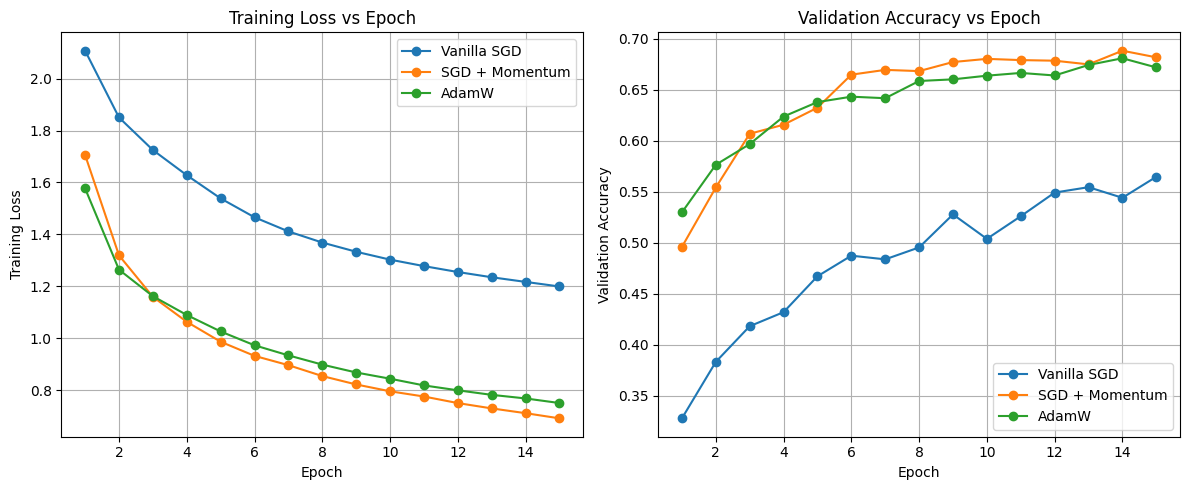


Final validation accuracies:
Vanilla SGD: 0.5648
SGD + Momentum: 0.6820
AdamW: 0.6721


In [5]:
import copy
import random
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# -------------------------
# Reproducibility
# -------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# -------------------------
# Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# Data
# -------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

full_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size], generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2)

# -------------------------
# Model: shallow CNN with only ONE fully connected layer
# -------------------------
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(32 * 8 * 8, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # 32 -> 16
        x = self.pool(torch.relu(self.conv2(x)))   # 16 -> 8
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

# -------------------------
# Train / Eval
# -------------------------
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        total += images.size(0)

    return running_loss / total


@torch.no_grad()
def evaluate_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / total


def run_experiment(optimizer_name, optimizer_fn, base_state, epochs=15):
    print(f"\n===== {optimizer_name} =====")

    model = CNN(num_classes=10).to(device)
    model.load_state_dict(copy.deepcopy(base_state))

    criterion = nn.CrossEntropyLoss()
    optimizer = optimizer_fn(model.parameters())

    train_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_acc = evaluate_accuracy(model, val_loader, device)

        train_losses.append(train_loss)
        val_accuracies.append(val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return model, train_losses, val_accuracies

# -------------------------
# Fair comparison: same initialization for all optimizers
# -------------------------
set_seed(42)
base_model = CNN(num_classes=10)
base_state = copy.deepcopy(base_model.state_dict())

optimizers_dict = {
    "Vanilla SGD": lambda params: optim.SGD(params, lr=0.01),
    "SGD + Momentum": lambda params: optim.SGD(params, lr=0.01, momentum=0.9),
    "AdamW": lambda params: optim.AdamW(params, lr=0.001)
}

results = {}

for name, opt_fn in optimizers_dict.items():
    model, train_losses, val_accuracies = run_experiment(
        name, opt_fn, base_state, epochs=15
    )
    results[name] = {
        "model": model,
        "train_losses": train_losses,
        "val_accuracies": val_accuracies
    }

# -------------------------
# Plot
# -------------------------
epochs = list(range(1, 16))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for name in results:
    plt.plot(epochs, results[name]["train_losses"], marker='o', label=name)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for name in results:
    plt.plot(epochs, results[name]["val_accuracies"], marker='o', label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Epoch")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nFinal validation accuracies:")
for name in results:
    print(f"{name}: {results[name]['val_accuracies'][-1]:.4f}")

### 1.B.1

SGD + Momentum achieves the lowest loss and validation accuracy for the first 15 epochs. From the first epoch itself momentum based methods provided better accuracy and loss as compared to the vanilla SGD. SGD + Momentum had higher training loss and highest validation accuracy as compared to AdamW initially, however performs better after 5 epochs. This is in line with the findings that SGD-Momentum works better after the initial where AdamW has better initialisation due to the moments and beta correction, as discussed above in 1.A.2.b

Using device: cuda

===== Training CNN with BatchNorm =====


Epoch [1/15] | Train Loss: 1.3875 | Val Acc: 0.6062
Epoch [2/15] | Train Loss: 1.0409 | Val Acc: 0.6209
Epoch [3/15] | Train Loss: 0.9333 | Val Acc: 0.6550
Epoch [4/15] | Train Loss: 0.8737 | Val Acc: 0.6803
Epoch [5/15] | Train Loss: 0.8208 | Val Acc: 0.6707
Epoch [6/15] | Train Loss: 0.7822 | Val Acc: 0.6833
Epoch [7/15] | Train Loss: 0.7489 | Val Acc: 0.6680
Epoch [8/15] | Train Loss: 0.7240 | Val Acc: 0.6851
Epoch [9/15] | Train Loss: 0.7042 | Val Acc: 0.6821
Epoch [10/15] | Train Loss: 0.6855 | Val Acc: 0.6895
Epoch [11/15] | Train Loss: 0.6594 | Val Acc: 0.6822
Epoch [12/15] | Train Loss: 0.6485 | Val Acc: 0.6947
Epoch [13/15] | Train Loss: 0.6331 | Val Acc: 0.6980
Epoch [14/15] | Train Loss: 0.6166 | Val Acc: 0.6860
Epoch [15/15] | Train Loss: 0.5987 | Val Acc: 0.6954

===== Training CNN without BatchNorm =====
Epoch [1/15] | Train Loss: 1.7102 | Val Acc: 0.5002
Epoch [2/15] | Train Loss: 1.3159 | Val Acc: 0.5538
Epoch [3/15] | Train Loss: 1.1666 | Val Acc: 0.6070
Epoch [4/15] |

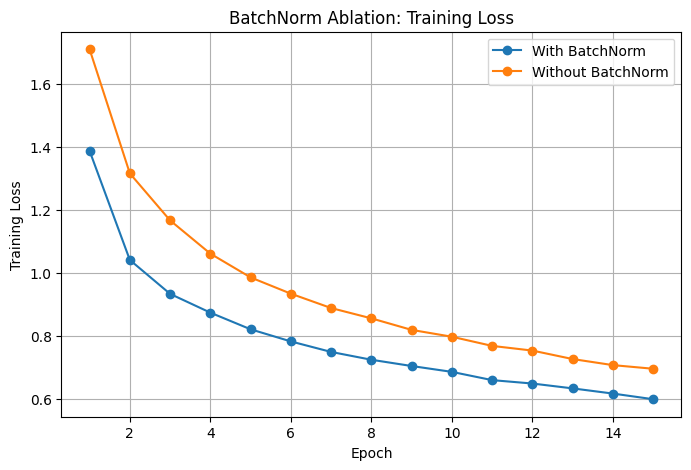


Final validation accuracy:
With BatchNorm:    0.6954
Without BatchNorm: 0.6798


In [6]:
import random
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# -------------------------
# Reproducibility
# -------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# -------------------------
# Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# Data
# -------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

full_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size], generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2)

# -------------------------
# Models: same architecture, one FC layer only
# -------------------------
class CNN_NoBN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(32 * 8 * 8, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


class CNN_BN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(32 * 8 * 8, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

# -------------------------
# Train / Eval
# -------------------------
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        total += images.size(0)

    return running_loss / total


@torch.no_grad()
def evaluate_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / total


def run_experiment(model_class, model_name, seed_for_init=42, epochs=15):
    print(f"\n===== Training {model_name} =====")

    # reset seed so both models start from the same conv/fc initialization
    set_seed(seed_for_init)
    model = model_class().to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    train_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_acc = evaluate_accuracy(model, val_loader, device)

        train_losses.append(train_loss)
        val_accuracies.append(val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return model, train_losses, val_accuracies

# -------------------------
# Run both ablations
# -------------------------
epochs = 15

model_bn, train_losses_bn, val_accs_bn = run_experiment(
    CNN_BN, "CNN with BatchNorm", seed_for_init=42, epochs=epochs
)

model_no_bn, train_losses_no_bn, val_accs_no_bn = run_experiment(
    CNN_NoBN, "CNN without BatchNorm", seed_for_init=42, epochs=epochs
)

# -------------------------
# Plot training loss curves
# -------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses_bn, marker='o', label='With BatchNorm')
plt.plot(range(1, epochs + 1), train_losses_no_bn, marker='o', label='Without BatchNorm')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("BatchNorm Ablation: Training Loss")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------
# Final validation accuracy
# -------------------------
print("\nFinal validation accuracy:")
print(f"With BatchNorm:    {val_accs_bn[-1]:.4f}")
print(f"Without BatchNorm: {val_accs_no_bn[-1]:.4f}")

### 1.B.2

This gap between validation accuracy exists because the model with batch normalisation has been trained on more stable inputs which have a good structure not which does not change batch by batch, hence allowing the model weights to focus more on learning representations to classify. During validation/test, batch norm uses the calculated batch statistics applied to input at each layer and hence the activations are normalised in a manner similar to training.

Using device: cuda

===== Training with CrossEntropyLoss =====
Epoch [1/40] | Train Loss: 1.3821 | Val Acc: 0.5980
Epoch [2/40] | Train Loss: 1.0384 | Val Acc: 0.6375
Epoch [3/40] | Train Loss: 0.9252 | Val Acc: 0.6658
Epoch [4/40] | Train Loss: 0.8643 | Val Acc: 0.6580
Epoch [5/40] | Train Loss: 0.8179 | Val Acc: 0.6740
Epoch [6/40] | Train Loss: 0.7854 | Val Acc: 0.6762
Epoch [7/40] | Train Loss: 0.7434 | Val Acc: 0.6960
Epoch [8/40] | Train Loss: 0.7243 | Val Acc: 0.6925
Epoch [9/40] | Train Loss: 0.6995 | Val Acc: 0.6893
Epoch [10/40] | Train Loss: 0.6738 | Val Acc: 0.6777
Epoch [11/40] | Train Loss: 0.6611 | Val Acc: 0.6938
Epoch [12/40] | Train Loss: 0.6408 | Val Acc: 0.6778
Epoch [13/40] | Train Loss: 0.6241 | Val Acc: 0.6915
Epoch [14/40] | Train Loss: 0.6126 | Val Acc: 0.6816
Epoch [15/40] | Train Loss: 0.5988 | Val Acc: 0.6979
Epoch [16/40] | Train Loss: 0.5903 | Val Acc: 0.6869
Epoch [17/40] | Train Loss: 0.5755 | Val Acc: 0.6853
Epoch [18/40] | Train Loss: 0.5663 | Val Acc:

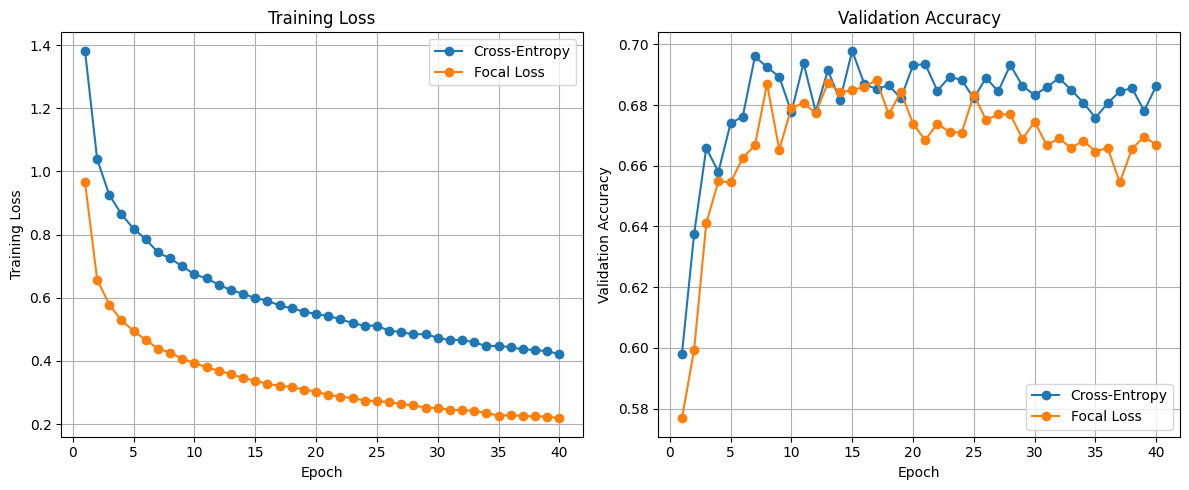

In [9]:
import copy
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# -------------------------
# Reproducibility
# -------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# -------------------------
# Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# Data
# -------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

full_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size], generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2)

# -------------------------
# BatchNorm CNN with one FC layer
# -------------------------
class CNN_BN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(32 * 8 * 8, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

# -------------------------
# Focal Loss
# FL(pt) = -alpha_t (1-pt)^gamma log(pt)
# -------------------------
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=1.0, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        else:
            return focal_loss

# -------------------------
# Train / Eval
# -------------------------
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        total += images.size(0)

    return running_loss / total


@torch.no_grad()
def evaluate_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / total


def run_experiment(loss_name, criterion, base_state, epochs=15):
    print(f"\n===== Training with {loss_name} =====")

    model = CNN_BN().to(device)
    model.load_state_dict(copy.deepcopy(base_state))

    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    train_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_acc = evaluate_accuracy(model, val_loader, device)

        train_losses.append(train_loss)
        val_accuracies.append(val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return model, train_losses, val_accuracies

# -------------------------
# Fair comparison: same initialization for CE and Focal
# -------------------------
set_seed(42)
base_model = CNN_BN()
base_state = copy.deepcopy(base_model.state_dict())

epochs = 40

ce_criterion = nn.CrossEntropyLoss()
focal_criterion = FocalLoss(gamma=2.0, alpha=1.0)

model_ce, ce_train_losses, ce_val_accs = run_experiment(
    "CrossEntropyLoss", ce_criterion, base_state, epochs=epochs
)

model_focal, focal_train_losses, focal_val_accs = run_experiment(
    "FocalLoss (gamma=2.0)", focal_criterion, base_state, epochs=epochs
)

# -------------------------
# Final validation accuracy
# -------------------------
print("\nFinal validation accuracies:")
print(f"Cross-Entropy: {ce_val_accs[-1]:.4f}")
print(f"Focal Loss:    {focal_val_accs[-1]:.4f}")

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), ce_train_losses, marker='o', label='Cross-Entropy')
plt.plot(range(1, epochs + 1), focal_train_losses, marker='o', label='Focal Loss')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), ce_val_accs, marker='o', label='Cross-Entropy')
plt.plot(range(1, epochs + 1), focal_val_accs, marker='o', label='Focal Loss')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 1.B.3 

Focal Loss provides a meaningful advantage over CE when there is a class imbalance or when model is overconfident on easy classifications and underconfident on hard classifcations. It suppresses loss corresponding to smaples with already high confidence using the term $(1-p_t)^\gamma$ and provides the model the gradients from class predictions with low confidence.

In [8]:
import random
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# -------------------------
# Reproducibility
# -------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# -------------------------
# Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# Data
# -------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

full_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size], generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)

# -------------------------
# BatchNorm CNN with one FC layer
# -------------------------
class CNN_BN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(32 * 8 * 8, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

def run_gradient_accumulation_experiment(epochs=5, accum_steps=4, max_optimizer_steps=50):
    model = CNN_BN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    optimizer_step_losses = []
    optimizer_step_count = 0

    model.train()
    optimizer.zero_grad()

    for epoch in range(epochs):
        running_loss = 0.0
        microbatch_count = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            # keep original loss for reporting
            running_loss += loss.item()

            # scale loss so accumulated gradient matches batch size 32
            (loss / accum_steps).backward()
            microbatch_count += 1

            if microbatch_count % accum_steps == 0:
                optimizer.step()
                optimizer.zero_grad()

                optimizer_step_count += 1
                step_loss = running_loss / accum_steps
                optimizer_step_losses.append(step_loss)

                print(
                    f"Optimizer step [{optimizer_step_count}/{max_optimizer_steps}] "
                    f"| Loss: {step_loss:.4f}"
                )

                running_loss = 0.0

                if optimizer_step_count >= max_optimizer_steps:
                    return model, optimizer_step_losses

    return model, optimizer_step_losses

model, optimizer_step_losses = run_gradient_accumulation_experiment(
    epochs=5,
    accum_steps=4,
    max_optimizer_steps=50
)

print("\nFirst 5 losses:", [round(x, 4) for x in optimizer_step_losses[:5]])
print("Last 5 losses: ", [round(x, 4) for x in optimizer_step_losses[-5:]])

if optimizer_step_losses[-1] < optimizer_step_losses[0]:
    print("\nThe loss is decreasing overall.")
else:
    print("\nThe loss is a bit noisy, but check the overall trend in the printed values.")

Using device: cuda
Optimizer step [1/50] | Loss: 2.4058
Optimizer step [2/50] | Loss: 2.7525
Optimizer step [3/50] | Loss: 2.5147
Optimizer step [4/50] | Loss: 2.5640
Optimizer step [5/50] | Loss: 2.4823
Optimizer step [6/50] | Loss: 2.2688
Optimizer step [7/50] | Loss: 2.2674
Optimizer step [8/50] | Loss: 2.4243
Optimizer step [9/50] | Loss: 2.2379
Optimizer step [10/50] | Loss: 2.4708
Optimizer step [11/50] | Loss: 2.4723
Optimizer step [12/50] | Loss: 2.7782
Optimizer step [13/50] | Loss: 2.4513
Optimizer step [14/50] | Loss: 1.8660
Optimizer step [15/50] | Loss: 2.6396
Optimizer step [16/50] | Loss: 2.4013
Optimizer step [17/50] | Loss: 2.9431
Optimizer step [18/50] | Loss: 2.2525
Optimizer step [19/50] | Loss: 2.2447
Optimizer step [20/50] | Loss: 2.6812
Optimizer step [21/50] | Loss: 3.4124
Optimizer step [22/50] | Loss: 2.6260
Optimizer step [23/50] | Loss: 2.3742
Optimizer step [24/50] | Loss: 2.7293
Optimizer step [25/50] | Loss: 2.3942
Optimizer step [26/50] | Loss: 2.1205
Op